In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
print(sys.path)

from BPMN.optimization import *
torch.set_default_dtype(torch.float64)
from libSOGAtruncate import truncate
import time

import torch
from torch.distributions import Normal, Categorical
import math

import BPMN.data_generating_process as dgp
import BPMN.helper_plots as hp
import matplotlib.pyplot as plt
import numpy as np


['/home/rdoz/miniconda3/envs/myenv/lib/python313.zip', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/lib-dynload', '', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages', '/home/rdoz/PhD/DeGAS/src']


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
compiledFile=compile2SOGA('programs/parallel.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
    'mu0':  1.,     # START
    'mu1':  6.,    # A_SUBMITTED
    'mu2':  6.,    # A_PARTLYSUBMITTED
    'mu3':  9.,   # W_Assess_fraud
    'mu4':  12.,  # W_Fix_incomplete_submission
    'mu5':  6.,    # A_PREACCEPTED
    'mu6':  9.,   # W_Complete_preaccepted_appl
    'mu7':  6.,    # A_ACCEPTED
    'mu8':  6.,    # A_FINALIZED
    'mu9':  6.,    # O_SELECTED
    'mu10': 6.,    # O_CREATED
    'mu11': 6.,    # O_SENT
    'mu12': 6.,   # W_Call_after_offer
    'mu13': 6.,    # O_SENT_BACK
    'mu14': 9.,   # W_Call_missing_information
    'mu15': 12.,  # W_Assess_application
    'mu16': 6.,    # O_CANCELLED
    'mu17': 6.,    # A_CANCELLED
    'mu18': 6.,    # A_DECLINED
    'mu19': 6.,    # O_DECLINED
    'mu20': 6.,    # O_ACCEPTED
    'mu21': 6.,    # A_APPROVED
    'mu22': 6.,    # A_REGISTERED
    'mu23': 6.,    # A_ACTIVATED
    'mu24': 1.,     # END

    'p0':  0.8,
    'p1':  0.3,
    'p2':  0.3,
    'p3':  0.8,
    'p4':  0.8,
    'p5':  0.7,
    'p6':  0.2,
    'p7':  0.8,
    'p8':  0.2,
    'p9':  0.4,
    'p10': 0.2,
    'p11': 0.7,
    'p12': 0.8,
    'p13': 0.2,
    'p14': 0.4,
    'p15': 0.8
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  components
1  com

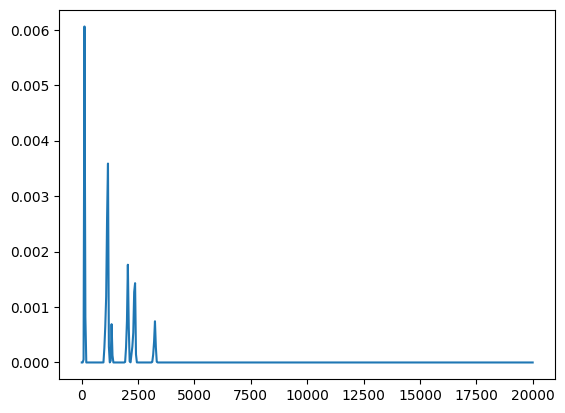

In [3]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 20000, 500)
plt.plot(xs.numpy(), pdf.numpy())

In [17]:
output_dist.gm.pi.shape

torch.Size([278, 1])

In [18]:
loss = lambda output_dist: -output_dist.gm.marg_pdf(torch.tensor([10000.]), output_dist.var_list.index('t'))
print(loss(output_dist))

tensor([[-2.3356e-05]], grad_fn=<NegBackward0>)


mu0: 7.745866733668299 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.36057978929237 mu4: 7.745866733668299 mu5: 22.36057978929237 mu6: 29.99990001065486 mu7: 29.99990001065486 mu8: 24.49479744088095 mu9: 17.320408094142092 mu10: 34.64091616060506 mu11: 24.49479744088095 mu12: 17.320408094142092 mu13: 42.42630687872721 mu14: 24.49479744088095 mu15: 17.320408094919465 mu16: 17.320408094919465 mu17: 24.4947974414307 mu18: 34.64091637910684 mu19: 17.320408094142092 mu20: 17.320408094142092 p0: 0.7070067995445987 p1: 0.7071067811865476 p2: 0.7072067628284964 p3: 0.8945271734642467 p4: 0.8945271694655704 p5: 0.44711363855937614  loss: -2.335558051180894e-05
mu0: 7.745766760469679 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.36047978918639 mu4: 7.745766760469679 mu5: 22.36047978918639 mu6: 29.999800006916256 mu7: 29.999800006916256 mu8: 24.49469743953206 mu9: 17.320308098186974 mu10: 34.640816155441854 mu11: 24.49469743953206 mu12: 17.320308098186974 mu13: 42.42620687187411 mu14: 24.49469743953206 mu1

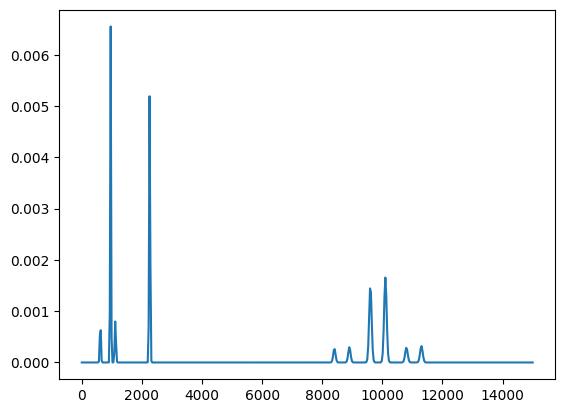

In [ ]:
params = {
    'mu0':  60.,    # Create Purchase Requisition
    'mu1':  900.,   # Analyze Purchase Requisition
    'mu2':  1300.,  # Amend Purchase Requisition
    'mu3':  500.,   # Create Request for Quotation
    'mu4':  60.,    # Analyze Request for Quotation
    'mu5':  500.,   # Amend Request for Quotation
    'mu6':  900.,   # Send Request for Quotation to Supplier
    'mu7':  900.,   # Create Quotation comparison Map
    'mu8':  600.,   # Analyze Quotation Comparison Map
    'mu9':  300.,   # Choose best option
    'mu10': 1200.,  # Settle Conditions With Supplier
    'mu11': 600.,   # Create Purchase Order
    'mu12': 300.,   # Confirm Purchase Order
    'mu13': 1800.,  # Deliver Goods Services
    'mu14': 600.,   # Release Purchase Order
    'mu15': 300.,   # Approve Purchase Order for payment
    'mu16': 300.,   # Send Invoice
    'mu17': 600.,   # Release Supplier's Invoice
    'mu18': 1200.,  # Settle Dispute With Supplier
    'mu19': 300.,   # Authorize Supplier's Invoice payment
    'mu20': 300.,   # Pay Invoice

    'p0': 0.5,  # after Create Purchase Requisition -> Analyze Purchase Requisition
    'p1': 0.5,  # after Analyze Purchase Requisition -> Amend Purchase Requisition
    'p2': 0.5,  # after Analyze Request for Quotation -> Amend Request for Quotation
    'p3': 0.8,  # after RFQ block -> Send Request for Quotation to Supplier
    'p4': 0.8,  # after Release Purchase Order -> Approve Purchase Order for payment
    'p5': 0.2   # after Release Supplier's Invoice -> Settle Dispute With Supplier
}

# square root all parameters to ensure positivity
for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)

start_time = time.time()
# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.0001)

end_time = time.time()
execution_time = end_time - start_time
print(f"Optimization execution time: {execution_time} seconds")

compiledFile=compile2SOGA('programs/purchasing.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg, params_dict)

xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 15000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.show()